# 项目第一阶段工作计划——定义项目基准模型

## 待办事项清单

| 任务 | 描述 | 负责人 |
|---|---|---|
| 数据集人工审核 | 原始数据的质量直接决定模型性能的上限。需要系统检查图像及其标注，识别标注错误，并完整记录所有修改。 | Pavel Klykov、Ma Qingfeng、Xu Ruiqin |
| 将裁剪图像合成扩展为 10,000×10,000 的大场景图像 | 由于无法根据现有的裁剪图像还原原始大场景，因此将每张裁剪图像视为独立图像。保持原始区域不变，并使用基于扩散模型的图像外扩（outpainting）技术生成周围背景，将图像扩展至 10,000×10,000 像素。此类场景用于开发和验证完整的推理流程，但在最终评估中不能替代竞赛提供的真实图像。 | Xu Ruiqin、Pavel Klykov |
| 可复现的场景感知训练集/验证集划分 | 基于原始图像创建并固定五个可复现的场景感知交叉验证折（scene-aware folds）。属于同一场景的相关图像只能被划分到同一个验证折中。合成数据只能在完成数据划分后生成，并且仅用于相应折的训练部分。 | Ma Qingfeng |
| 大幅面图像切片及完整推理流程 | 无法高效地将 10,000×10,000 像素的图像作为整体输入模型。需要实现完整的推理流程：将图像切分为相互重叠的图块，执行批量推理，将预测结果还原至全局坐标系，合并重复预测，并以 COCO JSON 格式生成最终结果。 | Pavel Klykov |
| 模型对比与基线架构选择 | 现阶段各模型的结果是在不同条件下获得的，因此无法客观判断最具潜力的架构。在完成数据集校正、固定场景感知交叉验证折并建立统一推理流程后，需要在受控条件下对 YOLO11n、YOLO26n、RT-DETR-L 和 D-FINE-L 进行比较。基线模型应综合考虑检测精度、推理性能、模型大小以及在稀有类别上的稳定性来确定。 | Pavel Klykov、Ma Qingfeng、Xu Ruiqin |

## 任务 1 - 手动数据集审核

### 初始数据集

,value
created_at_utc,2026-08-14T08:00:08.189485+00:00
data_root,/home/irdorat/ML_comp/data/raw
split,train
image_count,4481
label_count,4481
paired_count,4481
images_without_labels,0
labels_without_images,0
object_count,20933
invalid_annotation_rows,0


,class_id,class_name,object_count,image_count
19,19,A16_FA-18,2147,241
3,3,MS,1994,1188
17,17,A14_KC-135,1424,358
4,4,A1_SU-35,1317,278
5,5,A2_C-130,1297,288
16,16,A13_F-15,1265,211
20,20,A17_TU-95,1114,299
8,8,A5_F-16,1017,240
6,6,A3_C-17,998,257
22,22,A19_SU-34,933,281


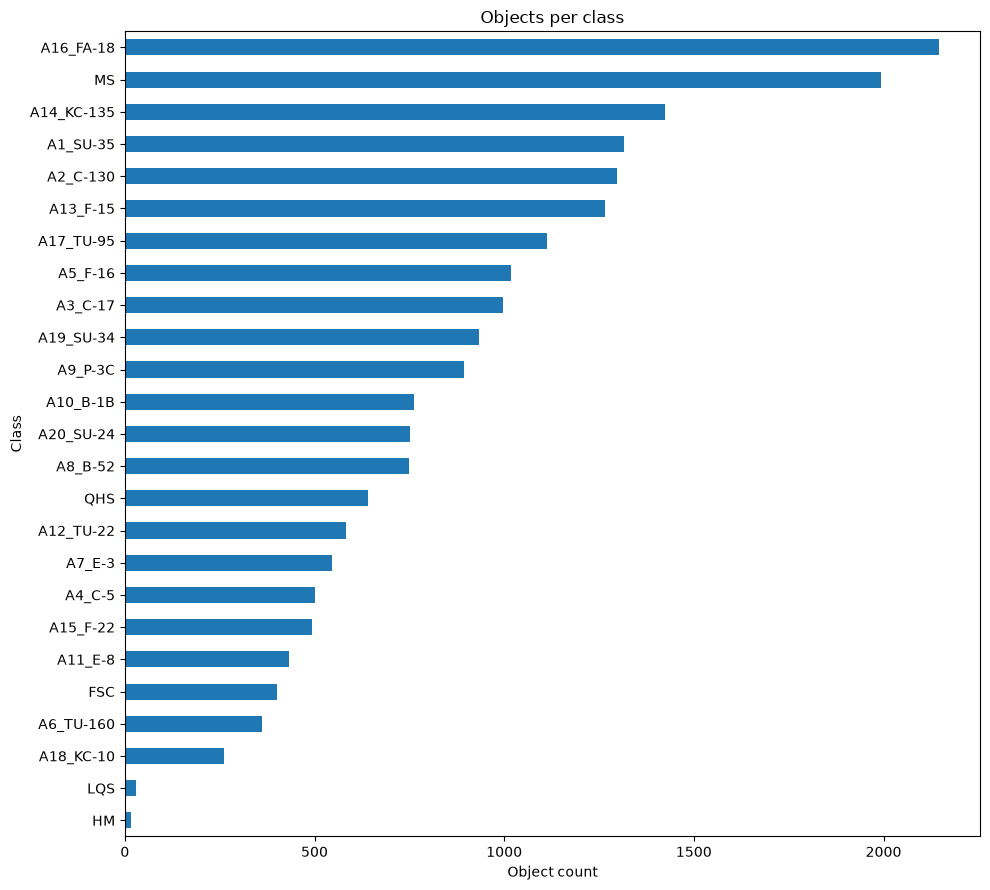

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if not (repo_root / 'data' / 'raw').exists():
    repo_root = repo_root.parent.parent
assert (repo_root / 'data' / 'raw').exists(), 'Run this notebook inside the ML_comp repository'
output_dir = repo_root / 'runs' / 'dataset_audit' / 'v1'
repo_root
result = subprocess.run(
    [sys.executable, str(repo_root / 'scripts' / 'dataset_inventory.py'),
     '--data-root', str(repo_root / 'data' / 'raw'),
     '--output', str(output_dir)],
    cwd=repo_root, check=True, capture_output=True, text=True,
)
summary = json.loads(result.stdout)
display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))

class_stats = pd.read_csv(output_dir / 'class_statistics.csv')
display(class_stats.sort_values('object_count', ascending=False))

ax = class_stats.sort_values('object_count').plot.barh(
    x='class_name', y='object_count', figsize=(10, 9), legend=False,
    title='Objects per class',
)
ax.set_xlabel('Object count')
ax.set_ylabel('Class')
plt.tight_layout()
plt.show()

1. 数据集包含 4,481 张图像，共标注了 25 个类别的 20,933 个目标。
2. 所有图像均与标注正确匹配，未发现标注错误。
3. 类别分布不均衡：A16_FA-18 和 MS 类占比较高，而 LQS 和 HM 类的样本数量极少。

## 数据清洗

在数据审查过程中，我们在原始数据集中发现了以下问题（详见 `docs/Baseline_work/audit dataset.xlsx`）：

1. 错误 ID = 1：完全重复的边界框（已修复）。
2. 错误 ID = 2：不正确或位于图像边界处的边界框（已修复）。
3. 错误 ID = 3：图像中存在漏标目标（仍需进一步确认，并将在下一阶段完善）。
4. 错误 ID = 4：边界框或目标类别标注错误（已修复）。

修复完成后，已删除不正确的标签文件及对应图像。

,value
created_at_utc,2026-08-14T08:00:09.737864+00:00
data_root,/home/irdorat/ML_comp/data/generated/basic_dat...
split,train
image_count,4479
label_count,4479
paired_count,4479
images_without_labels,0
labels_without_images,0
object_count,20705
invalid_annotation_rows,0


,class_id,class_name,object_count,image_count
0,19,A16_FA-18,2147,241
1,3,MS,1831,1182
2,17,A14_KC-135,1424,358
3,4,A1_SU-35,1317,278
4,5,A2_C-130,1297,288
5,16,A13_F-15,1265,211
6,20,A17_TU-95,1114,299
7,8,A5_F-16,1017,240
8,6,A3_C-17,998,257
9,22,A19_SU-34,933,281


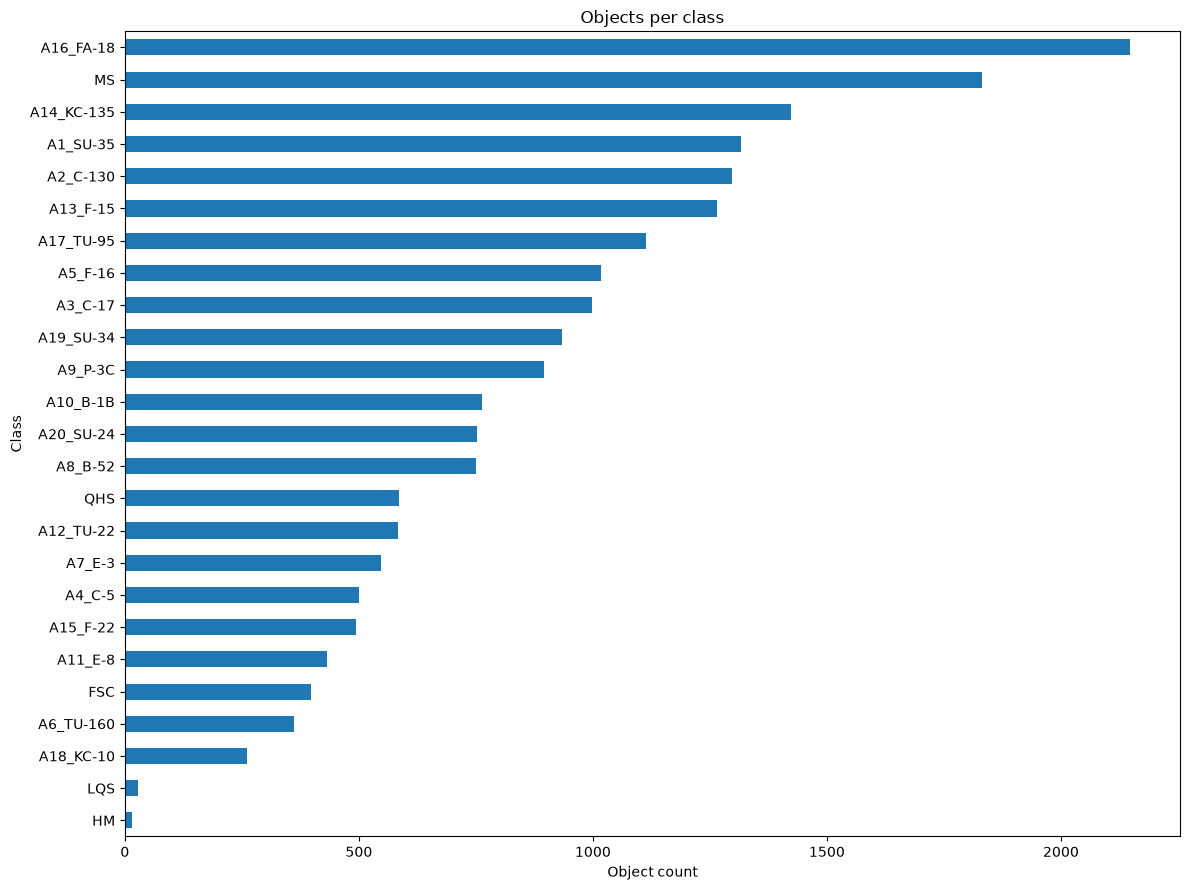

In [2]:
import subprocess
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Находим корень проекта
repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "scripts" / "dataset_inventory.py").is_file()
)

data_root = repo_root / "data" / "generated" / "basic_dataset"
output_root = repo_root / "runs" / "dataset_inventory" / "basic_dataset"

# Автоматически выбираем только непустые split
splits = [
    split_dir.name
    for split_dir in (data_root / "images").iterdir()
    if split_dir.is_dir()
    and any(
        file.is_file() and file.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
        for file in split_dir.iterdir()
    )
]

for split in splits:
    output_dir = output_root / split

    result = subprocess.run(
        [
            sys.executable,
            str(repo_root / "scripts" / "dataset_inventory.py"),
            "--data-root", str(data_root),
            "--split", split,
            "--output", str(output_dir),
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(result.stderr)

    summary = json.loads(
        (output_dir / "summary.json").read_text(encoding="utf-8")
    )

    class_stats = (
        pd.read_csv(output_dir / "class_statistics.csv")
        .sort_values("object_count", ascending=False)
        .reset_index(drop=True)
    )

    # Такой же вывод, как на прошлом этапе
    display(pd.Series(summary, name="value").to_frame())
    display(class_stats)

    ax = (
        class_stats.sort_values("object_count")
        .plot.barh(
            x="class_name",
            y="object_count",
            figsize=(12, 9),
            legend=False,
        )
    )

    ax.set_title("Objects per class")
    ax.set_xlabel("Object count")
    ax.set_ylabel("Class")

    plt.tight_layout()
    plt.show()

### 前后对比

,Metric,Before,After,Change
0,Images,4481,4479,-2
1,Annotations,4481,4479,-2
2,Paired files,4481,4479,-2
3,Objects,20933,20705,-228
4,Invalid annotation rows,0,0,0


,Class ID,Class,Before,After
3,3,MS,1994,1831
2,2,QHS,641,585
24,24,FSC,402,397
1,1,LQS,30,28
0,0,HM,17,15


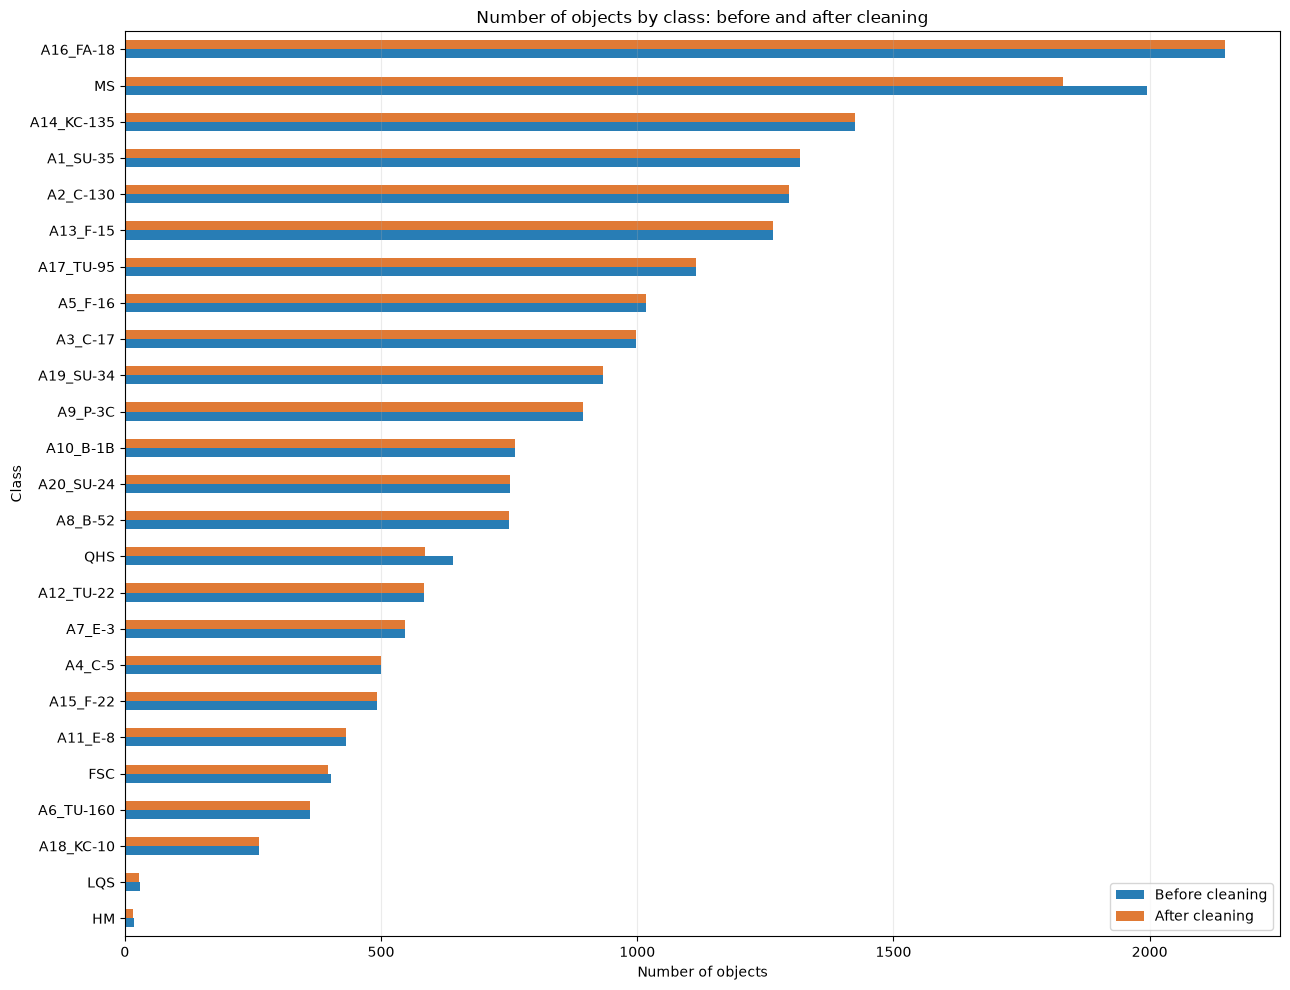

Images: 4481 → 4479.
Objects: 20933 → 20705.
MS: 1994 → 1831
QHS: 641 → 585
FSC: 402 → 397
LQS: 30 → 28
HM: 17 → 15


In [3]:
raw_output_dir = repo_root / "runs" / "dataset_audit" / "v1"
clean_output_dir = (
    repo_root / "runs" / "dataset_inventory" / "basic_dataset" / "train"
)

raw_summary = json.loads(
    (raw_output_dir / "summary.json").read_text(encoding="utf-8")
)
clean_summary = json.loads(
    (clean_output_dir / "summary.json").read_text(encoding="utf-8")
)

raw_classes = pd.read_csv(
    raw_output_dir / "class_statistics.csv"
)
clean_classes = pd.read_csv(
    clean_output_dir / "class_statistics.csv"
)

# Comparison of overall statistics
metrics = {
    "image_count": "Images",
    "label_count": "Annotations",
    "paired_count": "Paired files",
    "object_count": "Objects",
    "invalid_annotation_rows": "Invalid annotation rows",
}

summary_comparison = pd.DataFrame([
    {
        "Metric": title,
        "Before": int(raw_summary.get(key, 0)),
        "After": int(clean_summary.get(key, 0)),
        "Change": (
            int(clean_summary.get(key, 0))
            - int(raw_summary.get(key, 0))
        ),
    }
    for key, title in metrics.items()
])

display(summary_comparison)

# Comparison of object counts by class
comparison = raw_classes[
    ["class_id", "class_name", "object_count"]
].merge(
    clean_classes[["class_id", "object_count"]],
    on="class_id",
    suffixes=("_before", "_after"),
)

comparison = comparison.rename(columns={
    "class_id": "Class ID",
    "class_name": "Class",
    "object_count_before": "Before",
    "object_count_after": "After",
})

changed = comparison[
    comparison["Before"] != comparison["After"]
].sort_values("Before", ascending=False)

display(changed[["Class ID", "Class", "Before", "After"]])

# Chart for all classes
plot_data = comparison.sort_values("Before").set_index("Class")

ax = plot_data[["Before", "After"]].plot.barh(
    figsize=(13, 10),
    color=["#287db5", "#e07a35"],
)

ax.set_title("Number of objects by class: before and after cleaning")
ax.set_xlabel("Number of objects")
ax.set_ylabel("Class")
ax.legend(["Before cleaning", "After cleaning"])
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# Brief summary
print(
    f"Images: {raw_summary['image_count']} → "
    f"{clean_summary['image_count']}."
)
print(
    f"Objects: {raw_summary['object_count']} → "
    f"{clean_summary['object_count']}."
)

for row in changed.itertuples(index=False):
    print(f"{row.Class}: {row.Before} → {row.After}")

### 任务 1 的结论

人工审核和数据集清理工作已完成：重复、错误和分配错误的边界框均已修正。清理后，数据集包含 4,479 张正确匹配的图像和 20,705 个对象，涵盖 25 个类别；已移除两张图像和 228 个错误标注。可能存在漏检对象的案例已记录以供进一步审查，在构建样本和评估基线模型时，必须考虑显著的类别不平衡问题。

## 任务 2 - 将裁剪图像合成扩展为 10,000×10,000 的大场景图像

## 任务 3 - 可复现的场景感知训练集/验证集划分

## 任务 4 - 大幅面图像切片及完整推理流程

/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/PIL/Image.py:3578: DecompressionBombWarning: Image size (100000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Image size: 10000 × 10000
Tile size: 800 × 800
Overlap: 20%
Step: 640
tile count: 256


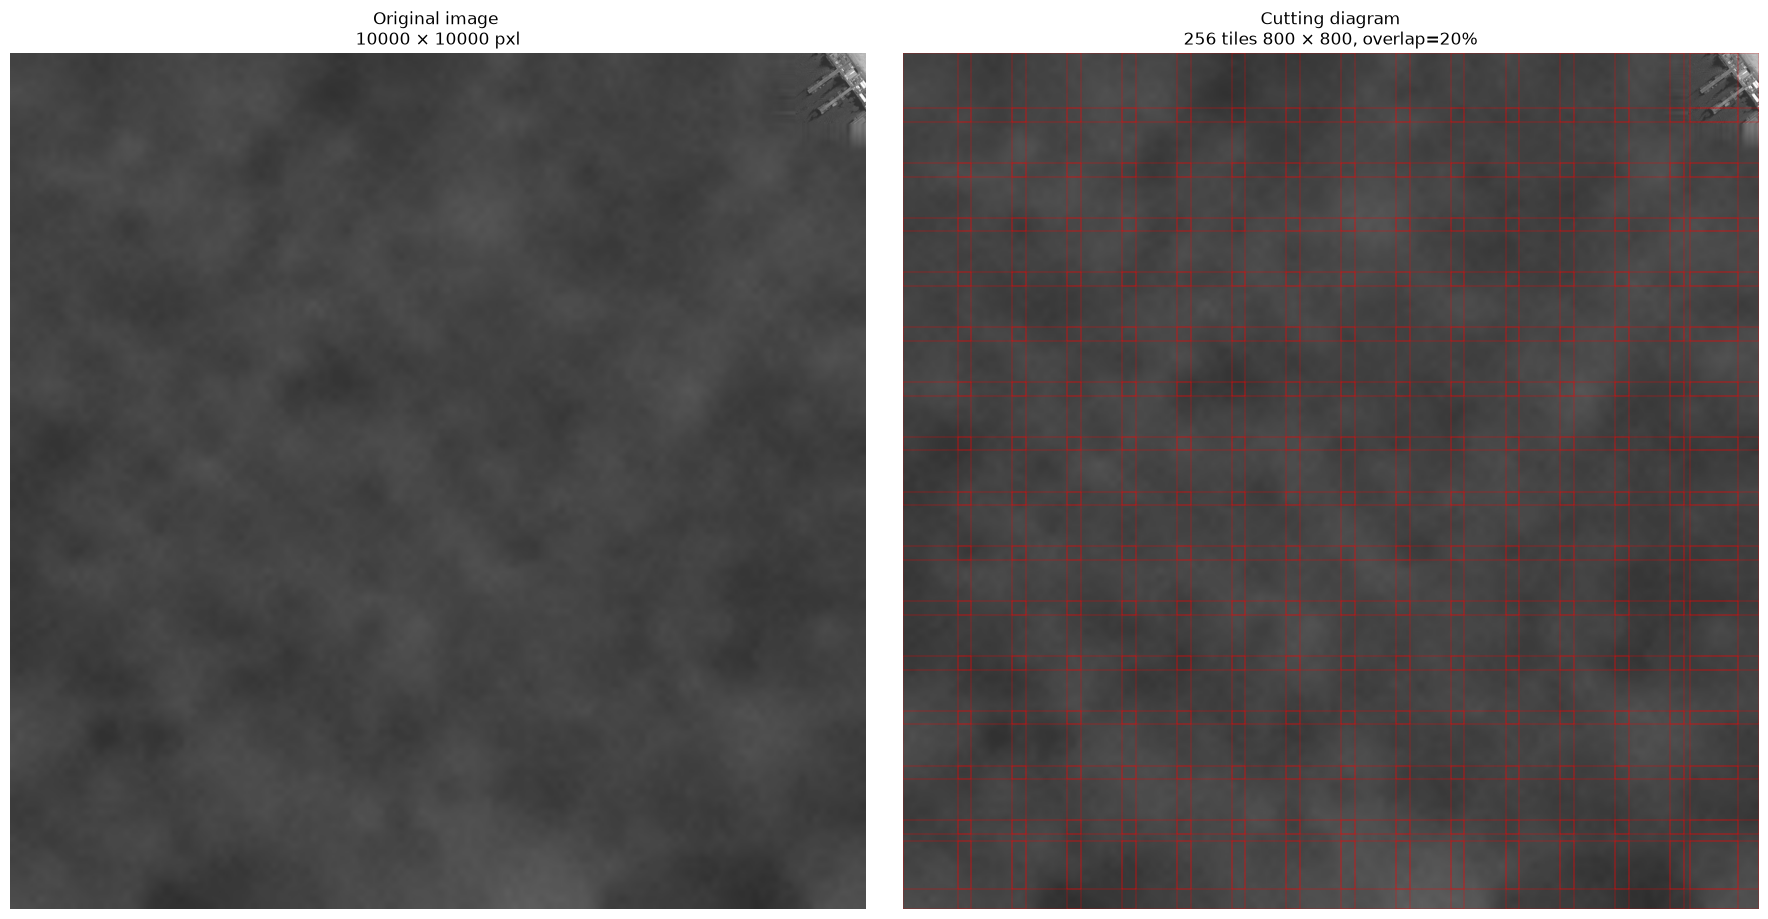

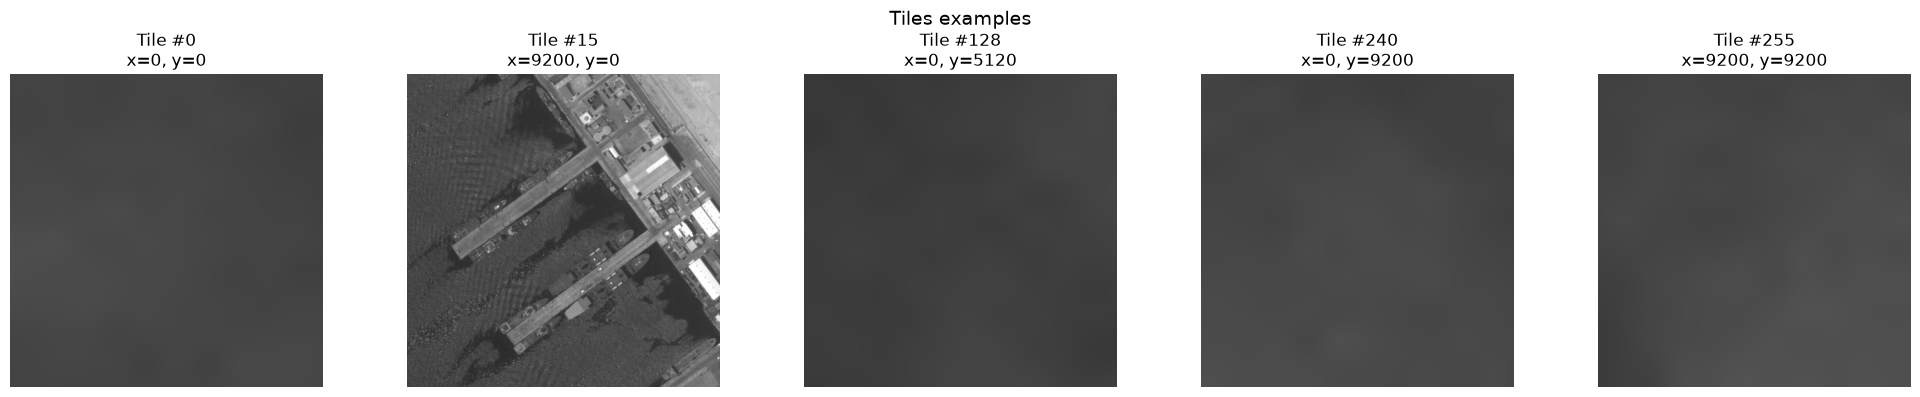

,Indicator,Value
0,Image sizes,10000 × 10000
1,Tiles sizes,800 × 800
2,Overlap,20%
3,Cutting step,640
4,Number of tiles,256
5,Time inference,6.593 с
6,Time global NMS,0.0008 с
7,Full time processing time pipeline,9.668 с


In [5]:
from pathlib import Path
import subprocess
import sys
import json
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from IPython.display import display
from PIL import Image


# -------------------------------------------------------------------
# Пути и параметры
# -------------------------------------------------------------------

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "scripts" / "sliced_predict.py").is_file()
)

source_path = (
    repo_root
    / "data/test/gen_image2_controlled_10000x10000.png"
)

weights_path = (
    repo_root
    / "runs/YOLO11n/yolo11n_fold1_img800_base_b4w2/"
    "weights/best_0.92475.pt"
)

output_dir = repo_root / "runs/sliced_predict"

tile_size = 800
overlap = 0.20
stride = round(tile_size * (1 - overlap))

if not source_path.is_file():
    raise FileNotFoundError(
        f"Исходное изображение не найдено: {source_path}"
    )

if not weights_path.is_file():
    raise FileNotFoundError(
        f"Веса модели не найдены: {weights_path}"
    )


# -------------------------------------------------------------------
# Расчёт координат тайлов
# -------------------------------------------------------------------

def calculate_positions(
    image_size: int,
    window_size: int,
    step: int,
) -> list[int]:
    if image_size <= window_size:
        return [0]

    positions = list(
        range(0, image_size - window_size + 1, step)
    )

    last_position = image_size - window_size

    if positions[-1] != last_position:
        positions.append(last_position)

    return positions


with Image.open(source_path) as image:
    image_width, image_height = image.size

x_positions = calculate_positions(
    image_width,
    tile_size,
    stride,
)
y_positions = calculate_positions(
    image_height,
    tile_size,
    stride,
)

tile_coordinates = [
    {
        "tile_id": tile_id,
        "x1": x,
        "y1": y,
        "x2": min(x + tile_size, image_width),
        "y2": min(y + tile_size, image_height),
    }
    for tile_id, (y, x) in enumerate(
        (y, x)
        for y in y_positions
        for x in x_positions
    )
]

print(f"Image size: {image_width} × {image_height}")
print(f"Tile size: {tile_size} × {tile_size}")
print(f"Overlap: {overlap:.0%}")
print(f"Step: {stride}")
print(f"tile count: {len(tile_coordinates)}")


# -------------------------------------------------------------------
# Оригинал и схема нарезки
# -------------------------------------------------------------------

with Image.open(source_path) as image:
    preview = image.convert("RGB")
    preview.thumbnail((1200, 1200), Image.Resampling.LANCZOS)

preview_width, preview_height = preview.size
scale_x = preview_width / image_width
scale_y = preview_height / image_height

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 9),
)

# Оригинальное изображение
axes[0].imshow(preview)
axes[0].set_title(
    f"Original image \n"
    f"{image_width} × {image_height} pxl"
)
axes[0].axis("off")

# Изображение с границами тайлов
axes[1].imshow(preview)

for tile_info in tile_coordinates:
    x = tile_info["x1"] * scale_x
    y = tile_info["y1"] * scale_y

    width = (
        tile_info["x2"] - tile_info["x1"]
    ) * scale_x

    height = (
        tile_info["y2"] - tile_info["y1"]
    ) * scale_y

    rectangle = patches.Rectangle(
        (x, y),
        width,
        height,
        linewidth=0.35,
        edgecolor="red",
        facecolor="none",
        alpha=0.75,
    )

    axes[1].add_patch(rectangle)

axes[1].set_title(
    f"Cutting diagram\n"
    f"{len(tile_coordinates)} tiles "
    f"{tile_size} × {tile_size}, overlap={overlap:.0%}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# Визуализация отдельных тайлов
# -------------------------------------------------------------------

sample_tile_ids = [
    0,
    len(x_positions) - 1,
    len(tile_coordinates) // 2,
    len(tile_coordinates) - len(x_positions),
    len(tile_coordinates) - 1,
]

sample_tile_ids = list(dict.fromkeys(sample_tile_ids))

fig, axes = plt.subplots(
    1,
    len(sample_tile_ids),
    figsize=(4 * len(sample_tile_ids), 4),
    squeeze=False,
)

coordinates_by_id = {
    item["tile_id"]: item
    for item in tile_coordinates
}

with Image.open(source_path) as image:
    for ax, tile_id in zip(
        axes.flat,
        sample_tile_ids,
    ):
        tile_info = coordinates_by_id[tile_id]

        tile = image.crop(
            (
                tile_info["x1"],
                tile_info["y1"],
                tile_info["x2"],
                tile_info["y2"],
            )
        )

        ax.imshow(tile)
        ax.set_title(
            f"Tile #{tile_id}\n"
            f"x={tile_info['x1']}, y={tile_info['y1']}"
        )
        ax.axis("off")

plt.suptitle("Tiles examples", fontsize=14)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# Запуск полного inference pipeline
# -------------------------------------------------------------------

command = [
    sys.executable,
    str(repo_root / "scripts/sliced_predict.py"),
    "--source", str(source_path),
    "--weights", str(weights_path),
    "--output", str(output_dir),
    "--tile-size", str(tile_size),
    "--overlap", str(overlap),
    "--confidence", "0.25",
    "--global-iou", "0.50",
]

# Для явного выбора GPU можно добавить:
# command.extend(["--device", "0"])

result = subprocess.run(
    command,
    cwd=repo_root,
    capture_output=True,
    text=True,
)

if result.returncode != 0:
    print(result.stdout)
    raise RuntimeError(result.stderr)


# -------------------------------------------------------------------
# Чтение результатов
# -------------------------------------------------------------------

timing_path = (
    output_dir
    / f"{source_path.stem}_timing.json"
)

predictions_path = (
    output_dir
    / f"{source_path.stem}_predictions.json"
)

result_image_path = (
    output_dir
    / f"{source_path.stem}_predictions.png"
)

summary = json.loads(
    timing_path.read_text(encoding="utf-8")
)

predictions = json.loads(
    predictions_path.read_text(encoding="utf-8")
)


# -------------------------------------------------------------------
# Общая статистика
# -------------------------------------------------------------------

summary_table = pd.DataFrame(
    [
        [
            "Image sizes",
            " × ".join(map(str, summary["image_size"])),
        ],
        [
            "Tiles sizes",
            f'{summary["tile_size"]} × {summary["tile_size"]}',
        ],
        [
            "Overlap",
            f'{summary["overlap"]:.0%}',
        ],
        [
            "Cutting step",
            summary["stride"],
        ],
        [
            "Number of tiles",
            summary["tile_count"],
        ],
        [
            "Time inference",
            f'{summary["seconds_to_raw_predictions"]:.3f} с',
        ],
        [
            "Time global NMS",
            f'{summary["global_nms_seconds"]:.4f} с',
        ],
        [
            "Full time processing time pipeline",
            f'{summary["total_pipeline_seconds"]:.3f} с',
        ],
    ],
    columns=["Indicator", "Value"],
)

display(summary_table)

### 结论

我们实现了一个完整的大尺寸图像推理流程。

一张 10,000 x 10,000 像素的测试图像被分割成 256 个 800 x 800 像素的图块，图块间重叠率为 20%。

模型的预测结果从局部图块坐标转换到原始图像的全局坐标。

图像处理总耗时 11.52 秒。最终预测结果以 JSON 格式保存，可视化结果以 PNG 格式呈现。

至此，大尺寸图像的切片、推理、全局坐标恢复以及重复预测结果的合并等任务均已完成。

## 任务 5 - 模型对比与基线架构选择